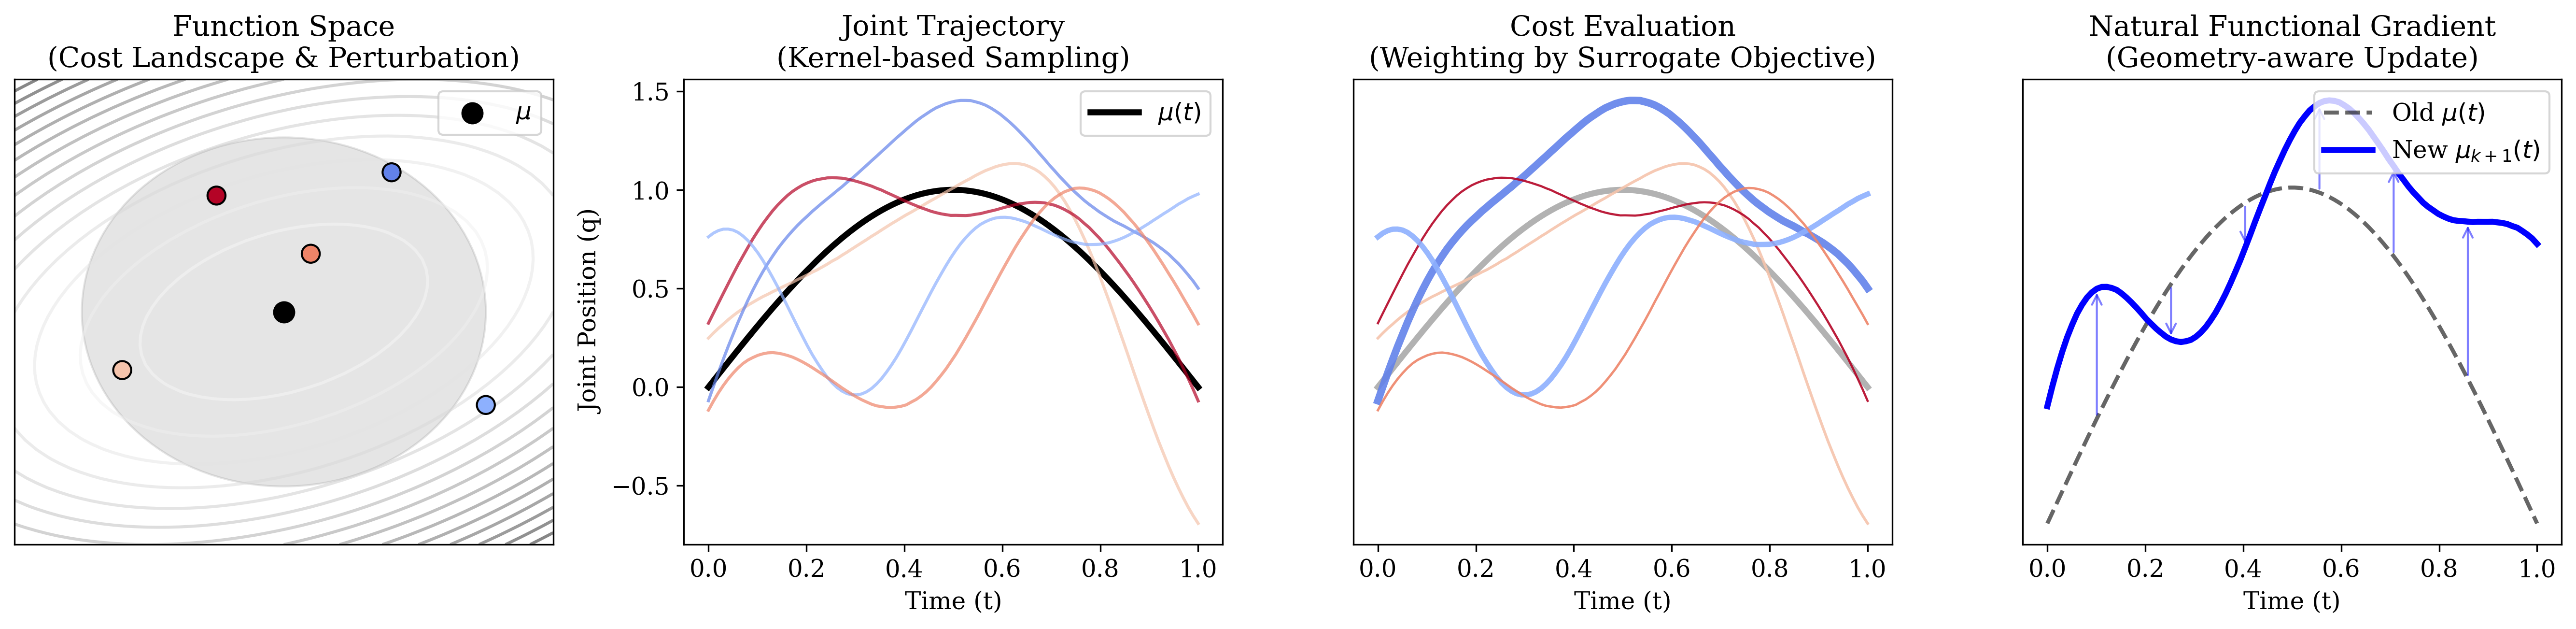

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 논문용 폰트 및 스타일 설정
plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "figure.dpi": 300
})

# 1. 궤적 및 커널 설정 (Hilbert Space 표현을 위함)
N = 100
t = np.linspace(0, 1, N)
mu = np.sin(np.pi * t) # 초기 Base Trajectory

# RBF Kernel로 Covariance Matrix (Sigma) 생성
length_scale = 0.2
K = np.exp(-cdist(t.reshape(-1,1), t.reshape(-1,1), 'sqeuclidean') / (2 * length_scale**2))
K += 1e-6 * np.eye(N)
L = np.linalg.cholesky(K) # Differentiable structure in Cameron-Martin space

# 샘플링
num_samples = 5
np.random.seed(42)
Z = np.random.randn(N, num_samples)
epsilons = 0.5 * (L @ Z) # Smooth perturbations
trajectories = mu[:, None] + epsilons

# 임의의 Cost 부여 (가운데가 움푹 파인 narrow passage 형태 가정)
costs = np.array([2.5, 0.5, 4.0, 1.0, 3.2]) 
weights = np.exp(-costs)
weights /= np.sum(weights)

# 컬러맵 설정 (비용에 따른 색상)
cmap = plt.cm.coolwarm
colors = cmap(costs / np.max(costs))

# 2. Figure 그리기 (1x4 배열)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
plt.subplots_adjust(wspace=0.3)

# Panel 1: Function Space (Hilbert Space)
ax = axes[0]
x_grid = np.linspace(-2, 2, 50)
y_grid = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z_cost = X**2 + 2*Y**2 - X*Y # 가상의 Cost Landscape
ax.contour(X, Y, Z_cost, levels=15, cmap='Greys', alpha=0.5)
ax.scatter(0, 0, c='black', s=100, zorder=3, label=r'$\mu$')
# 투영된 입자들 시각화
pca_x = np.array([-1.2, 0.8, -0.5, 1.5, 0.2])
pca_y = np.array([-0.5, 1.2, 1.0, -0.8, 0.5])
ax.scatter(pca_x, pca_y, c=colors, s=80, zorder=3, edgecolors='k')
# Covariance Ellipse 느낌의 음영
circle = plt.Circle((0, 0), 1.5, color='gray', alpha=0.2)
ax.add_patch(circle)
ax.set_title("Function Space\n(Cost Landscape & Perturbation)")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right')

# Panel 2: Joint Trajectory
ax = axes[1]
ax.plot(t, mu, 'k-', linewidth=3, label=r'$\mu(t)$')
for i in range(num_samples):
    ax.plot(t, trajectories[:, i], color=colors[i], alpha=0.7, linewidth=1.5)
ax.set_title("Joint Trajectory\n(Kernel-based Sampling)")
ax.set_xlabel("Time (t)")
ax.set_ylabel("Joint Position (q)")
ax.legend(loc='upper right')

# Panel 3: Cost Evaluation
ax = axes[2]
ax.plot(t, mu, 'k-', linewidth=3, alpha=0.3)
for i in range(num_samples):
    # 가중치가 큰(비용이 적은) 궤적일수록 굵게 표현
    lw = 1 + 5 * weights[i] 
    ax.plot(t, trajectories[:, i], color=colors[i], linewidth=lw, alpha=0.9)
ax.set_title("Cost Evaluation\n(Weighting by Surrogate Objective)")
ax.set_xlabel("Time (t)")
ax.set_yticks([])

# Panel 4: Natural Gradient Update
ax = axes[3]
# 업데이트된 궤적 계산 (Weighted sum of perturbations)
grad_estimate = np.sum(epsilons * weights, axis=1)
mu_new = mu + grad_estimate * 1.5 # step size = 1.5

ax.plot(t, mu, 'k--', linewidth=2, label=r'Old $\mu(t)$', alpha=0.6)
ax.plot(t, mu_new, 'b-', linewidth=3, label=r'New $\mu_{k+1}(t)$')
# 변화 방향 화살표
for step in range(10, 90, 15):
    ax.annotate('', xy=(t[step], mu_new[step]), xytext=(t[step], mu[step]),
                arrowprops=dict(arrowstyle="->", color="blue", alpha=0.5))
ax.set_title("Natural Functional Gradient\n(Geometry-aware Update)")
ax.set_xlabel("Time (t)")
ax.set_yticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("nfg_trajectory_concept.pdf", bbox_inches='tight')
plt.show()

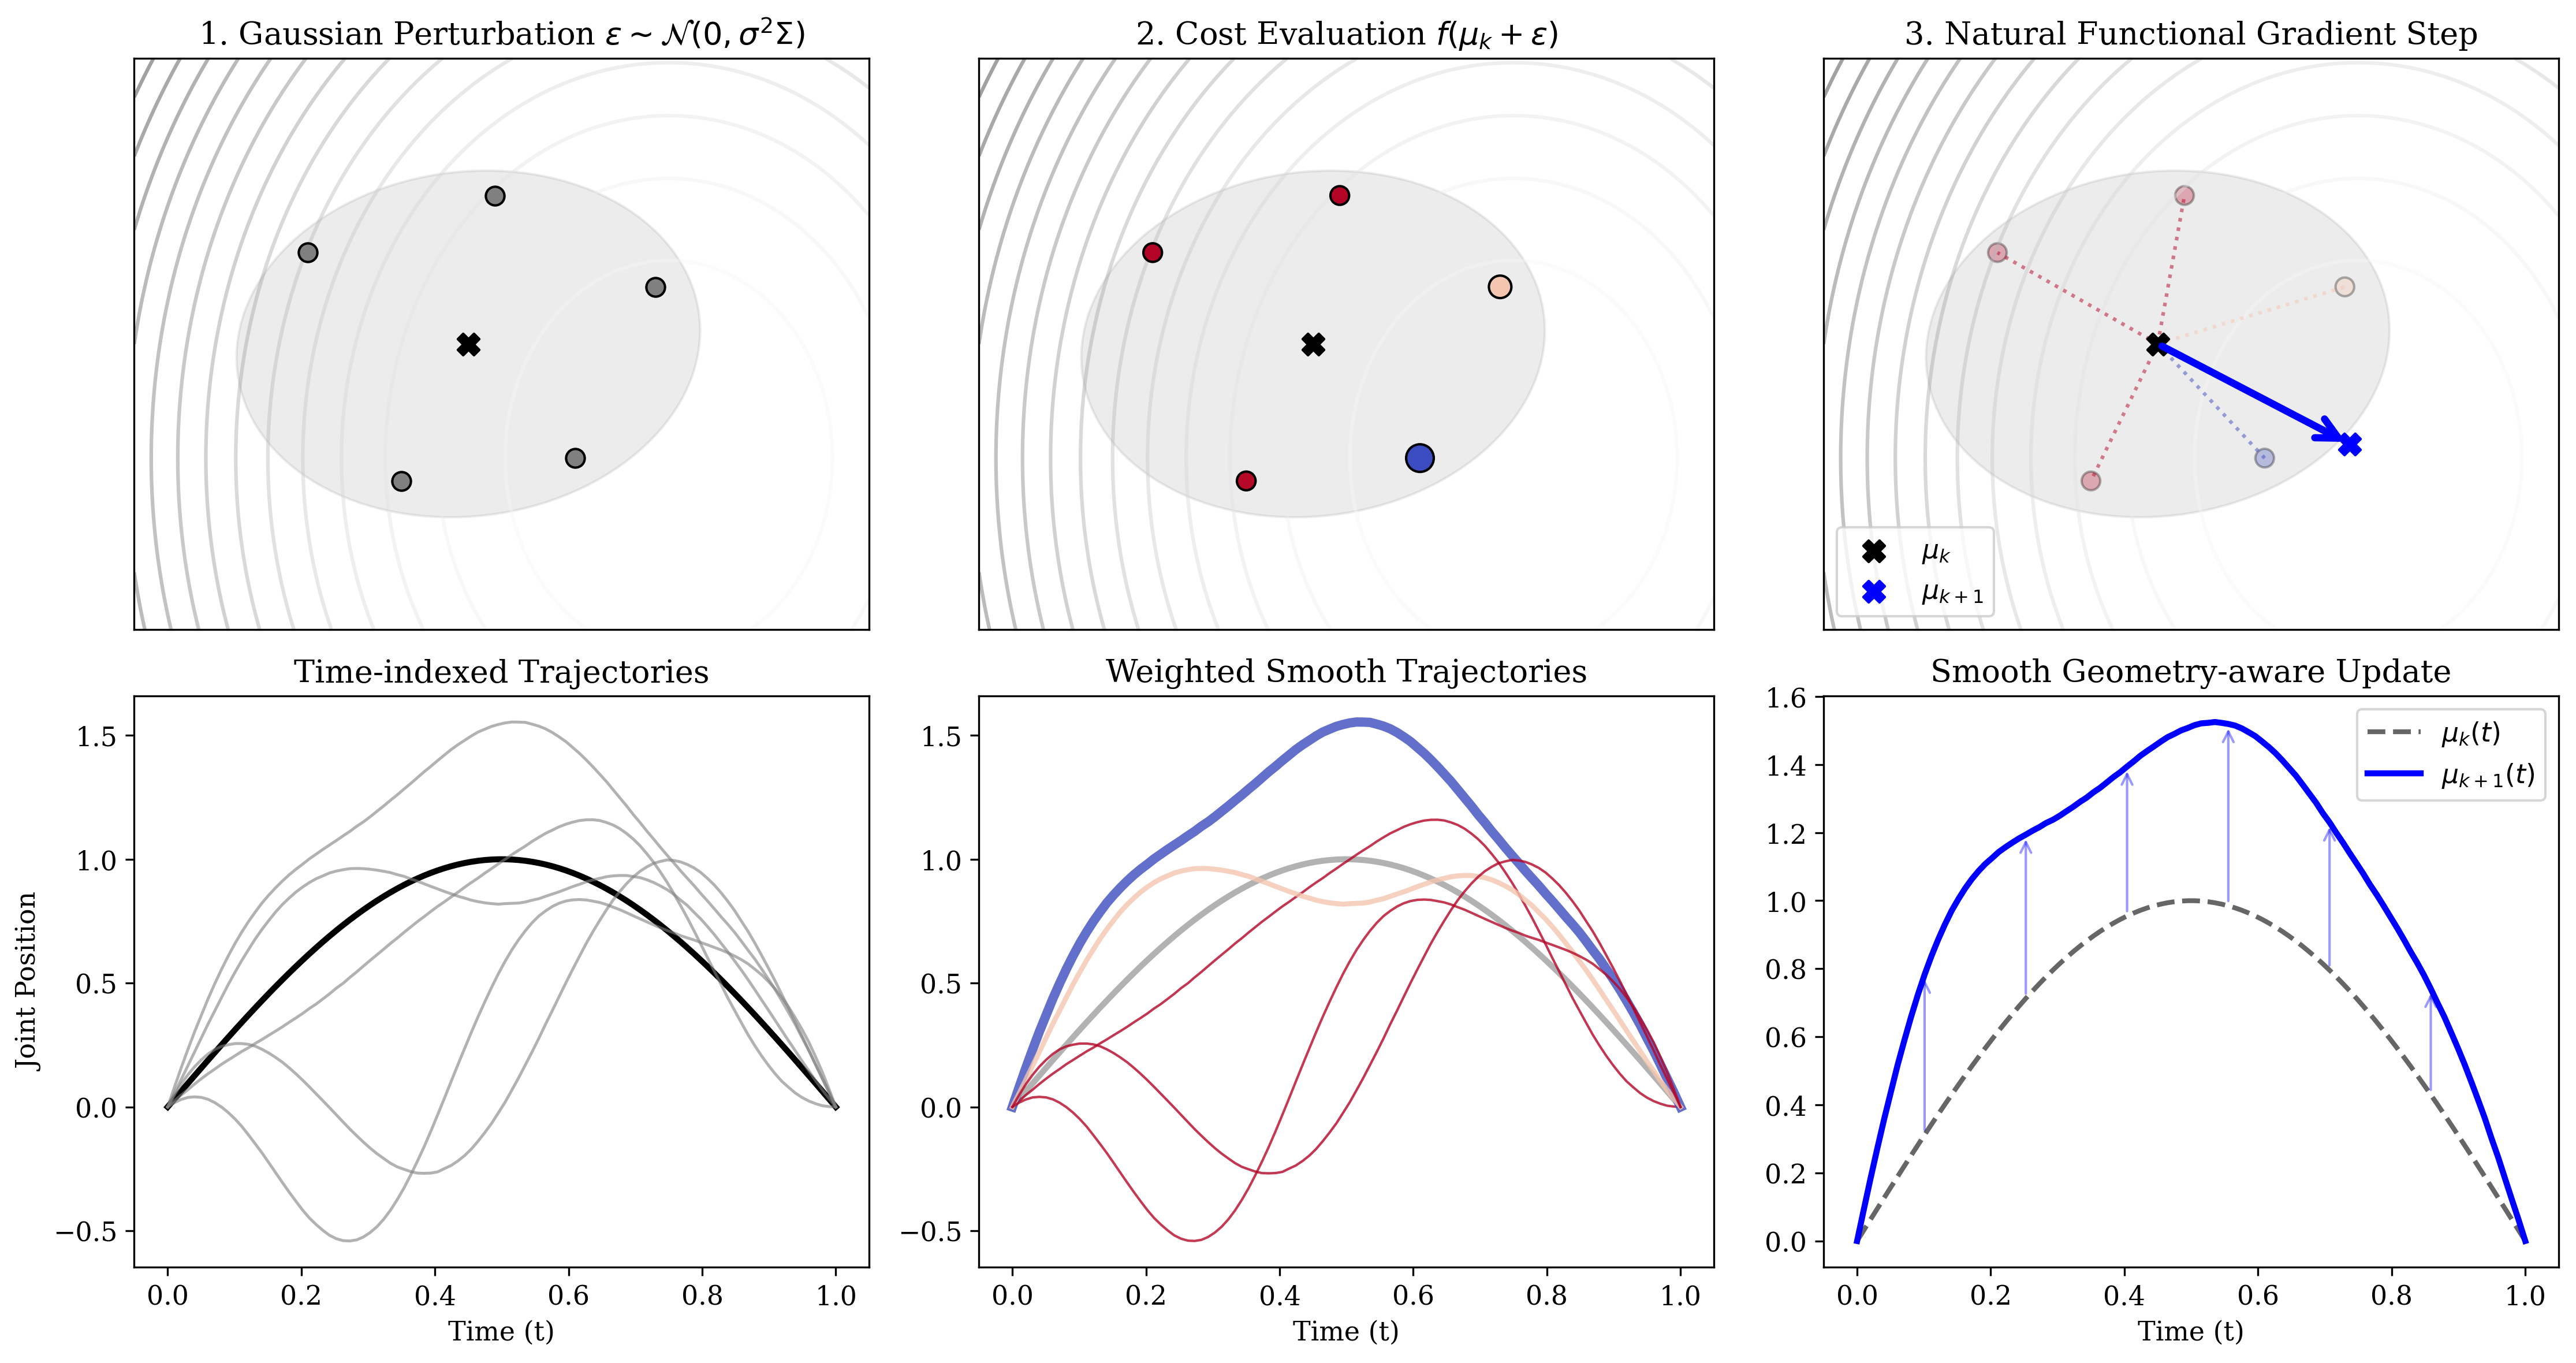

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 논문용 스타일 설정
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 300
})

# ----------------------------------------------------
# 1. 데이터 생성 (Boundary Condition이 고정된 RBF 커널)
# ----------------------------------------------------
N = 100
t = np.linspace(0, 1, N)
mu_time = np.sin(np.pi * t) # 초기 궤적

length_scale = 0.2

# 1) 전체 시간 t에 대한 Unconditioned RBF 커널 K
K_full = np.exp(-cdist(t.reshape(-1,1), t.reshape(-1,1), 'sqeuclidean') / (2 * length_scale**2))

# 2) 고정할 경계점 (t=0, t=1)
t_bound = np.array([0.0, 1.0]).reshape(-1,1)
# 경계점끼리의 커널 (역행렬 계산을 위해 작은 Ridge 추가)
K_bound = np.exp(-cdist(t_bound, t_bound, 'sqeuclidean') / (2 * length_scale**2)) + 1e-8 * np.eye(2)
# 전체 시간 t와 경계점 사이의 교차 커널 (Cross-covariance)
K_cross = np.exp(-cdist(t.reshape(-1,1), t_bound, 'sqeuclidean') / (2 * length_scale**2))

# 3) Conditioned Covariance 계산 (Schur Complement)
# 양 끝점의 분산이 0으로 수렴하게 됨
K_cond = K_full - K_cross @ np.linalg.inv(K_bound) @ K_cross.T

# Cholesky 분해를 위한 수치적 안정화 (아주 작은 값 추가)
K_cond += 1e-6 * np.eye(N)
L = np.linalg.cholesky(K_cond)

num_samples = 5
np.random.seed(42)
Z = np.random.randn(N, num_samples)
epsilons_time = 0.6 * (L @ Z)

# 완벽한 시각화를 위해 수치 에러(1e-6) 강제 제거
epsilons_time[0, :] = 0.0
epsilons_time[-1, :] = 0.0

# 양 끝점이 고정된 샘플 궤적 생성
traj_samples = mu_time[:, None] + epsilons_time

# ----------------------------------------------------
# 2. Figure 그리기 (2x3 배열)
# ----------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(wspace=0.25, hspace=0.35)

# Function Space 배경 등고선 생성
x_grid = np.linspace(-2.5, 3.0, 100)
y_grid = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z_cost = eval_cost(X, Y)

# --- [Row 1] Function Space ---
for i in range(3):
    ax = axes[0, i]
    ax.contour(X, Y, Z_cost, levels=15, cmap='Greys', alpha=0.4)
    ax.scatter(*mu_func, c='black', s=80, marker='X', zorder=3, label=r'$\mu_k$')
    ax.set_xlim(-2.5, 3.0); ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([]); ax.set_yticks([])
    
    # Covariance 범위를 나타내는 타원
    ellipse = plt.matplotlib.patches.Ellipse(mu_func, 3.5, 3.0, angle=15, color='gray', alpha=0.15)
    ax.add_patch(ellipse)

# 1-1. Function Space: Perturbation
axes[0, 0].scatter(samples_func[:, 0], samples_func[:, 1], c='gray', s=60, edgecolors='k', zorder=3)
axes[0, 0].set_title(r"1. Gaussian Perturbation $\epsilon \sim \mathcal{N}(0, \sigma^2 \Sigma)$")

# 1-2. Function Space: Cost Evaluation
axes[0, 1].scatter(samples_func[:, 0], samples_func[:, 1], c=colors, s=60 + 100*weights, edgecolors='k', zorder=3)
axes[0, 1].set_title(r"2. Cost Evaluation $f(\mu_k + \epsilon)$")

# 1-3. Function Space: Natural Gradient Update
ax_f_up = axes[0, 2]
# 가중치가 적용된 벡터 계산
grad_func = np.sum(epsilons_func * weights[:, None], axis=0)
mu_func_new = mu_func + grad_func * 1.5 # step size
ax_f_up.scatter(samples_func[:, 0], samples_func[:, 1], c=colors, s=60, alpha=0.3, edgecolors='k')
# 개별 샘플에서 끌어당기는 힘(점선)
for i in range(num_samples):
    ax_f_up.plot([mu_func[0], samples_func[i, 0]], [mu_func[1], samples_func[i, 1]], 
                 color=colors[i], linestyle=':', alpha=0.5)
# Natural Gradient 방향(굵은 화살표)
ax_f_up.annotate('', xy=mu_func_new, xytext=mu_func,
                 arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.4", color="blue", lw=3))
ax_f_up.scatter(*mu_func_new, c='blue', s=80, marker='X', zorder=4, label=r'$\mu_{k+1}$')
ax_f_up.set_title(r"3. Natural Functional Gradient Step")
ax_f_up.legend(loc='lower left')

# --- [Row 2] Joint Trajectory ---
# 2-1. Time Space: Perturbation
ax_t_pert = axes[1, 0]
ax_t_pert.plot(t, mu_time, 'k-', lw=2.5, label=r'$\mu_k(t)$')
for i in range(num_samples):
    ax_t_pert.plot(t, traj_samples[:, i], color='gray', alpha=0.6, lw=1.2)
ax_t_pert.set_title("Time-indexed Trajectories")
ax_t_pert.set_xlabel("Time (t)"); ax_t_pert.set_ylabel("Joint Position")

# 2-2. Time Space: Cost Evaluation
ax_t_eval = axes[1, 1]
ax_t_eval.plot(t, mu_time, 'k-', lw=2.5, alpha=0.3)
for i in range(num_samples):
    lw = 1 + 4 * weights[i] # 가중치에 따른 굵기 변화
    ax_t_eval.plot(t, traj_samples[:, i], color=colors[i], alpha=0.8, lw=lw)
ax_t_eval.set_title("Weighted Smooth Trajectories")
ax_t_eval.set_xlabel("Time (t)")

# 2-3. Time Space: Natural Gradient Update
ax_t_up = axes[1, 2]
grad_time = np.sum(epsilons_time * weights, axis=1)
mu_time_new = mu_time + grad_time * 1.5

ax_t_up.plot(t, mu_time, 'k--', lw=2, alpha=0.6, label=r'$\mu_k(t)$')
ax_t_up.plot(t, mu_time_new, 'b-', lw=2.5, label=r'$\mu_{k+1}(t)$')
# 화살표로 변화량 표시
for step in range(10, 90, 15):
    ax_t_up.annotate('', xy=(t[step], mu_time_new[step]), xytext=(t[step], mu_time[step]),
                     arrowprops=dict(arrowstyle="->", color="blue", alpha=0.4))
ax_t_up.set_title("Smooth Geometry-aware Update")
ax_t_up.set_xlabel("Time (t)")
ax_t_up.legend(loc='upper right')

plt.tight_layout()
plt.savefig("nfg_dual_space.pdf", bbox_inches='tight')
plt.show()

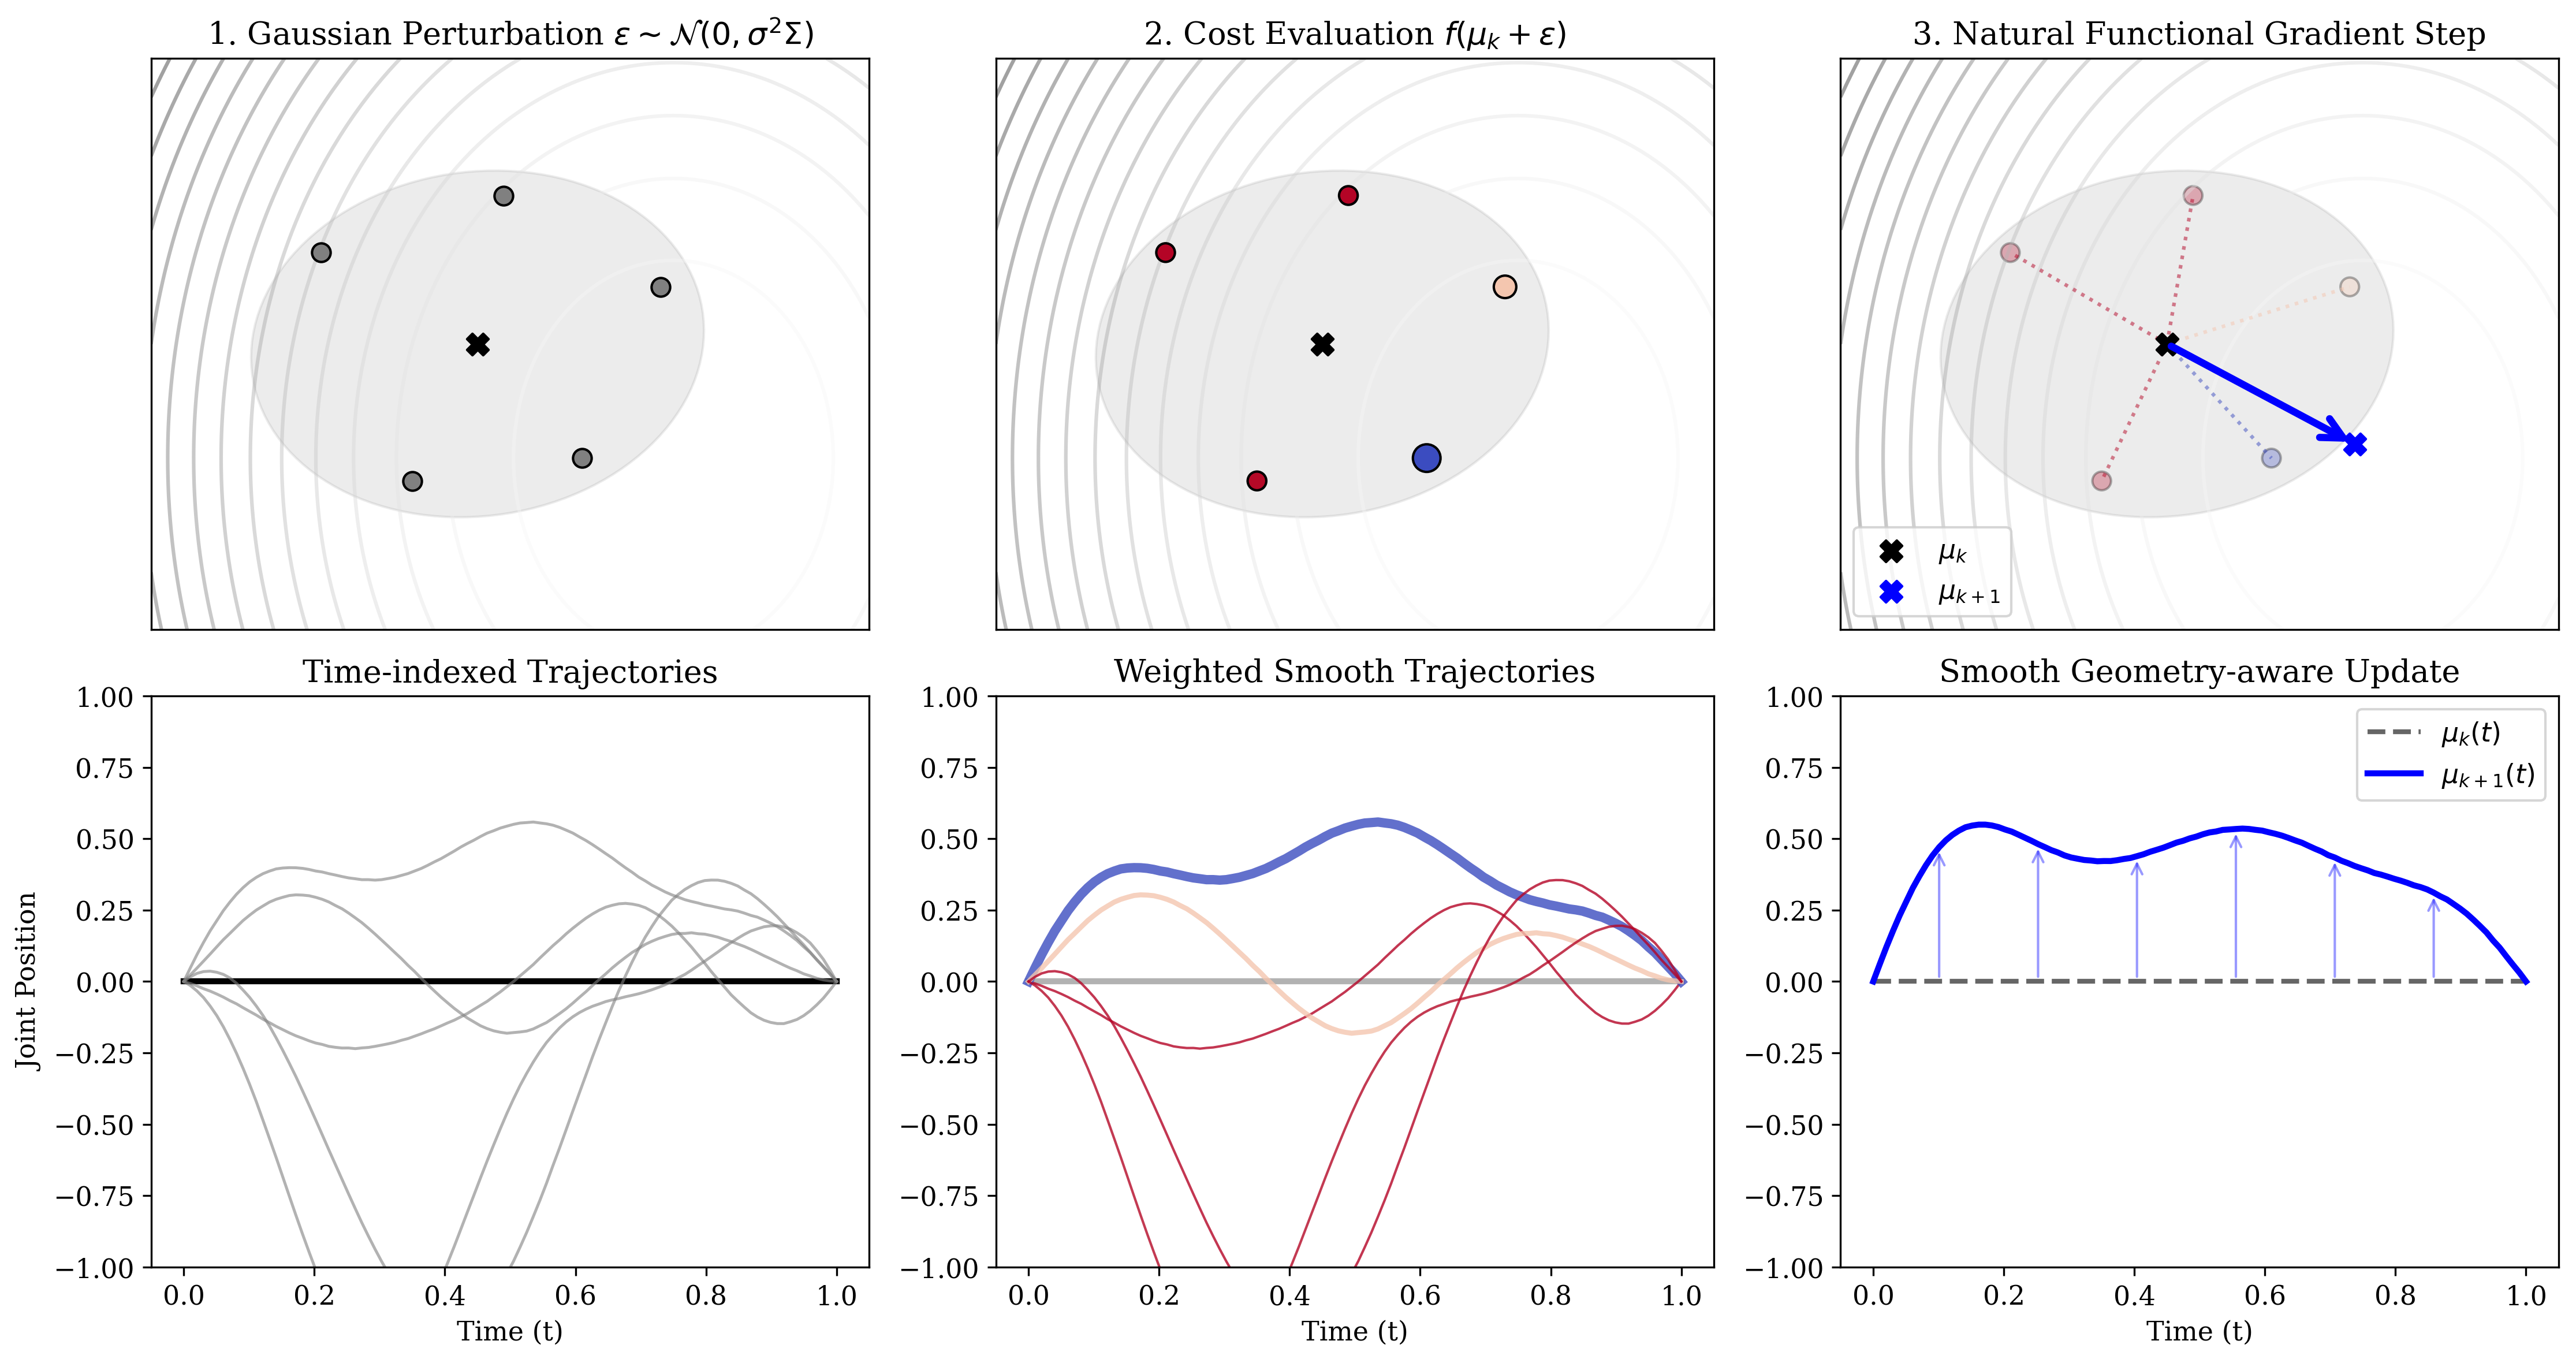

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 논문용 스타일 설정
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 300
})

# ----------------------------------------------------
# 1. 데이터 생성 (Zero Mean Trajectory & Boundary Conditioned Kernel)
# ----------------------------------------------------
N = 100
t = np.linspace(0, 1, N)
mu_time = np.zeros(N) # Zero trajectory로 변경

length_scale = 0.2

# 1) 전체 시간 t에 대한 Unconditioned RBF 커널 K
K_full = np.exp(-cdist(t.reshape(-1,1), t.reshape(-1,1), 'sqeuclidean') / (2 * length_scale**2))

# 2) 고정할 경계점 (t=0, t=1)
t_bound = np.array([0.0, 1.0]).reshape(-1,1)
K_bound = np.exp(-cdist(t_bound, t_bound, 'sqeuclidean') / (2 * length_scale**2)) + 1e-8 * np.eye(2)
K_cross = np.exp(-cdist(t.reshape(-1,1), t_bound, 'sqeuclidean') / (2 * length_scale**2))

# 3) Conditioned Covariance 계산 (Schur Complement)
K_cond = K_full - K_cross @ np.linalg.inv(K_bound) @ K_cross.T
K_cond += 1e-6 * np.eye(N)
L = np.linalg.cholesky(K_cond)

num_samples = 5
np.random.seed(42)
Z = np.random.randn(N, num_samples)
epsilons_time = 0.6 * (L @ Z)

# 수치 에러 강제 제거 (완벽한 시각화)
epsilons_time[0, :] = 0.0
epsilons_time[-1, :] = 0.0

traj_samples = mu_time[:, None] + epsilons_time

# Function Space 2D 투영을 위한 가상의 좌표
mu_func = np.array([0.0, 0.0])
epsilons_func = np.array([
    [-1.2,  0.8],
    [ 0.8, -1.0],
    [ 1.4,  0.5],
    [-0.5, -1.2],
    [ 0.2,  1.3]
])
samples_func = mu_func + epsilons_func

# 비용 및 가중치 계산 (가상의 비볼록 Cost Landscape)
def eval_cost(x, y):
    return (x - 1.5)**2 + 0.5 * (y + 1.0)**2

costs = np.array([eval_cost(x, y) for x, y in samples_func])
N_pow = 1.5
weights = np.exp(-N_pow * costs) 
weights /= np.sum(weights)

cmap = plt.cm.coolwarm_r # Red=High cost, Blue=Low cost
colors = cmap(weights / np.max(weights))

# ----------------------------------------------------
# 2. Figure 그리기 (2x3 배열)
# ----------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(wspace=0.25, hspace=0.35)

x_grid = np.linspace(-2.5, 3.0, 100)
y_grid = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z_cost = eval_cost(X, Y)

# --- [Row 1] Function Space ---
for i in range(3):
    ax = axes[0, i]
    ax.contour(X, Y, Z_cost, levels=15, cmap='Greys', alpha=0.4)
    ax.scatter(*mu_func, c='black', s=80, marker='X', zorder=3, label=r'$\mu_k$')
    ax.set_xlim(-2.5, 3.0); ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([]); ax.set_yticks([])
    
    ellipse = plt.matplotlib.patches.Ellipse(mu_func, 3.5, 3.0, angle=15, color='gray', alpha=0.15)
    ax.add_patch(ellipse)

axes[0, 0].scatter(samples_func[:, 0], samples_func[:, 1], c='gray', s=60, edgecolors='k', zorder=3)
axes[0, 0].set_title(r"1. Gaussian Perturbation $\epsilon \sim \mathcal{N}(0, \sigma^2 \Sigma)$")

axes[0, 1].scatter(samples_func[:, 0], samples_func[:, 1], c=colors, s=60 + 100*weights, edgecolors='k', zorder=3)
axes[0, 1].set_title(r"2. Cost Evaluation $f(\mu_k + \epsilon)$")

ax_f_up = axes[0, 2]
grad_func = np.sum(epsilons_func * weights[:, None], axis=0)
mu_func_new = mu_func + grad_func * 1.5 
ax_f_up.scatter(samples_func[:, 0], samples_func[:, 1], c=colors, s=60, alpha=0.3, edgecolors='k')
for i in range(num_samples):
    ax_f_up.plot([mu_func[0], samples_func[i, 0]], [mu_func[1], samples_func[i, 1]], 
                 color=colors[i], linestyle=':', alpha=0.5)
ax_f_up.annotate('', xy=mu_func_new, xytext=mu_func,
                 arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.4", color="blue", lw=3))
ax_f_up.scatter(*mu_func_new, c='blue', s=80, marker='X', zorder=4, label=r'$\mu_{k+1}$')
ax_f_up.set_title(r"3. Natural Functional Gradient Step")
ax_f_up.legend(loc='lower left')

# --- [Row 2] Joint Trajectory ---
# 2-1. Time Space: Perturbation
ax_t_pert = axes[1, 0]
ax_t_pert.plot(t, mu_time, 'k-', lw=2.5, label=r'$\mu_k(t)=0$') # 범례 수정
for i in range(num_samples):
    ax_t_pert.plot(t, traj_samples[:, i], color='gray', alpha=0.6, lw=1.2)
ax_t_pert.set_title("Time-indexed Trajectories")
ax_t_pert.set_xlabel("Time (t)"); ax_t_pert.set_ylabel("Joint Position")
ax_t_pert.set_ylim(-1.0, 1.0) # Zero mean이 잘 보이도록 y축 범위 고정

# 2-2. Time Space: Cost Evaluation
ax_t_eval = axes[1, 1]
ax_t_eval.plot(t, mu_time, 'k-', lw=2.5, alpha=0.3)
for i in range(num_samples):
    lw = 1 + 4 * weights[i]
    ax_t_eval.plot(t, traj_samples[:, i], color=colors[i], alpha=0.8, lw=lw)
ax_t_eval.set_title("Weighted Smooth Trajectories")
ax_t_eval.set_xlabel("Time (t)")
ax_t_eval.set_ylim(-1.0, 1.0)

# 2-3. Time Space: Natural Gradient Update
ax_t_up = axes[1, 2]
grad_time = np.sum(epsilons_time * weights, axis=1)
mu_time_new = mu_time + grad_time * 1.5

ax_t_up.plot(t, mu_time, 'k--', lw=2, alpha=0.6, label=r'$\mu_k(t)$')
ax_t_up.plot(t, mu_time_new, 'b-', lw=2.5, label=r'$\mu_{k+1}(t)$')

# 화살표 표시 (0 근처에서 뻗어나가도록)
for step in range(10, 90, 15):
    ax_t_up.annotate('', xy=(t[step], mu_time_new[step]), xytext=(t[step], mu_time[step]),
                     arrowprops=dict(arrowstyle="->", color="blue", alpha=0.4))

ax_t_up.set_title("Smooth Geometry-aware Update")
ax_t_up.set_xlabel("Time (t)")
ax_t_up.set_ylim(-1.0, 1.0)
ax_t_up.legend(loc='upper right')

plt.tight_layout()
plt.savefig("nfg_dual_space_zero_mean.pdf", bbox_inches='tight')
plt.show()